# Visualizzare la durata di degenza al Pronto Soccorso con PROC BOX


## Sintesi esecutiva

Un'analisi delle operazioni ospedaliere che utilizza PROC BOXPLOT (con alias PROC BOX) per confrontare la durata di degenza al pronto soccorso tra tre servizi clinici. I box plot schematici affiancati mostrano a colpo d'occhio mediana, quartili, media e valori anomali di lunga degenza per ciascun servizio.

Su 100 accessi simulati, la durata mediana di degenza aumenta costantemente da **40.0 ore in Medicina** a **50.4 ore in Chirurgia** fino a **60.5 ore in Traumatologia**, e le medie seguono lo stesso ordine (41.6, 54.6, 62.8 ore). La Chirurgia presenta tre valori anomali elevati oltre il baffo superiore (fino a 84.3 ore) — i casi di stazionamento (boarding) che consumano il maggior numero di ore-letto. Il notebook traccia il confronto in tre modi: un grafico schematico, una sovrapposizione dell'andamento medio e un layout orizzontale.

## Fonti dei dati

Tutti i dati sono generati inline dal primo DATA step (`call streaminit(20260531)`); non viene utilizzato alcun input esterno o di rete.

**`ed_los`** — una riga per ogni accesso al pronto soccorso (100 righe)

| Variabile | Tipo | Descrizione |
|----------|------|-------------|
| `PatientID` | Num | Identificatore sequenziale dell'accesso (1-100) |
| `Department` | Char(12) | Servizio di ammissione: Medicina, Chirurgia, Traumatologia |
| `Severity` | Char(8) | Gravità del triage: Ordinario (~55%), Urgente (~30%), Critico (~15%) |
| `LOS_Hours` | Num | Durata di degenza in ore; una media determinata dal servizio e dalla gravità più rumore normale, con un occasionale shock di lunga degenza (etichettata "Durata di degenza (ore)") |

Il mix realizzato è di 34 accessi in Medicina / 36 in Chirurgia / 30 in Traumatologia, e 51 Routine / 35 Urgent / 14 Critical per gravità di triage.

# Visualizzare la durata di degenza al Pronto Soccorso con PROC BOX

La durata di degenza (LOS) è una delle metriche operative più attentamente monitorate in un pronto soccorso ospedaliero: determina la disponibilità di posti letto, la dotazione di personale, il flusso dei pazienti e i punteggi di qualità. Le sole medie nascondono la storia — ciò che conta per un team operativo è la *dispersione* delle degenze, i *valori anomali* che impegnano le risorse e come le distribuzioni differiscono tra i servizi clinici.

PROC BOX (un alias di PROC BOXPLOT) è progettato appositamente per questo confronto. Traccia box-and-whisker plot affiancati, segnando mediana, quartili, media e osservazioni estreme di ciascun gruppo, così che un analista possa leggere a colpo d'occhio la forma della distribuzione della LOS di ogni servizio.

In questo notebook:

1. Generiamo un dataset sintetico di accessi al pronto soccorso adatto all'ambiente a 100 osservazioni.
2. Produciamo un box plot schematico della LOS per reparto, con la relativa tabella di statistiche.
3. Sovrapponiamo una linea di andamento medio con `BOXCONNECT=MEAN` per rendere esplicito il gradiente tra servizi.
4. Ridisegniamo lo stesso confronto in orizzontale con `HORIZONTAL`.

## Passo 1 — Generare dati sintetici di accessi al pronto soccorso

Simuliamo 100 accessi al pronto soccorso. Ogni paziente è assegnato a uno di tre servizi clinici (Medicine, Surgery, Trauma) e a una gravità di triage (Routine, Urgent, Critical). La durata di degenza è costruita a partire da una linea di base specifica del servizio, spostata verso l'alto per i pazienti a maggiore gravità, con rumore distribuito normalmente. Una piccola frazione di accessi riceve un ulteriore shock di lunga degenza per imitare la pesante coda a destra che i dati reali del pronto soccorso mostrano sempre (stazionamento, ricoveri in attesa di un posto letto di degenza). Il seme fisso in `call streaminit` rende il dataset pienamente riproducibile.

In [1]:
OPZIONI linesize=96;

DATI ed_los;
   CHIAMARE streaminit(20260531);
   LUNGHEZZA Department $ 14 Severity $ 10;
   VETTORE depts[3] $ 14 _temporary_ ('Medicina' 'Chirurgia' 'Traumatologia');
   VETTORE sevp[3]  $ 10 _temporary_ ('Ordinario' 'Urgente' 'Critico');
   FARE PatientID = 1 FINO_A 100;
      d = rand('integer', 1, 3);
      Department = depts[d];

      u = rand('uniform');
      SE_COND u < 0.55 ALLORA s = 1;
      ALTRIMENTI SE_COND u < 0.85 ALLORA s = 2;
      ALTRIMENTI s = 3;
      Severity = sevp[s];

      BASE = 24 + 10*d + 14*(s - 1);
      LOS_Hours = BASE + rand('normal', 0, 7);
      SE_COND rand('uniform') < 0.06 ALLORA
         LOS_Hours = LOS_Hours + rand('uniform', 40, 90);
      SE_COND LOS_Hours < 2 ALLORA LOS_Hours = 2;
      LOS_Hours = round(LOS_Hours, 0.1);
      USCITA;
   FINE;
   RIMUOVERE d u s BASE;
   ETICHETTA LOS_Hours = "Durata di degenza (ore)"
             Department = "Reparto"
             Severity   = "Gravità";
ESEGUIRE;


NOTE: Option LINESIZE changed to 96.
NOTE: DATA ed_los


NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


## Passo 2 — Ordinare in base alla variabile di gruppo

PROC BOX si aspetta che la variabile di gruppo (asse orizzontale) sia ordinata, in modo che le osservazioni di ogni gruppo siano contigue. Ordiniamo in base a `Department` prima di tracciare il grafico.

In [2]:
PROCEDURA ORDINARE DATI=ed_los;
   PER Department;
ESEGUIRE;


NOTE: PROC SORT data=ed_los

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from ed_los.
NOTE: Wrote ed_los (100 rows, 4 columns).
NOTE: PROC SORT statement used.


## Passo 3 — Box plot schematico

L'analisi centrale. La sintassi `PLOT analysis-var * group-var` richiede un box per ogni reparto. `BOXSTYLE=SCHEMATIC` produce un classico grafico schematico di Tukey: i baffi si estendono fino alle osservazioni più estreme entro 1.5 volte lo scarto interquartile, e qualsiasi punto oltre tale limite è disegnato individualmente come valore anomalo — ideale per individuare i casi di lunga degenza che mettono sotto pressione la capacità.

`NOHLABEL` sopprime l'etichetta ridondante dell'asse orizzontale, dato che i nomi dei reparti si spiegano da soli. Accanto al grafico, PROC BOXPLOT stampa una tabella di statistiche che riporta per ogni reparto N, minimo, quartili, mediana, massimo, media e deviazione standard.

                              Durata di degenza al PS per reparto                               

                              Durata di degenza al PS per reparto

                                     The BOXPLOT Procedure

Schematic Plots for Durata di degenza (ore)

Reparto               N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgia            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicina             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Traumatologia        30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Durata di degenza al PS per reparto.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


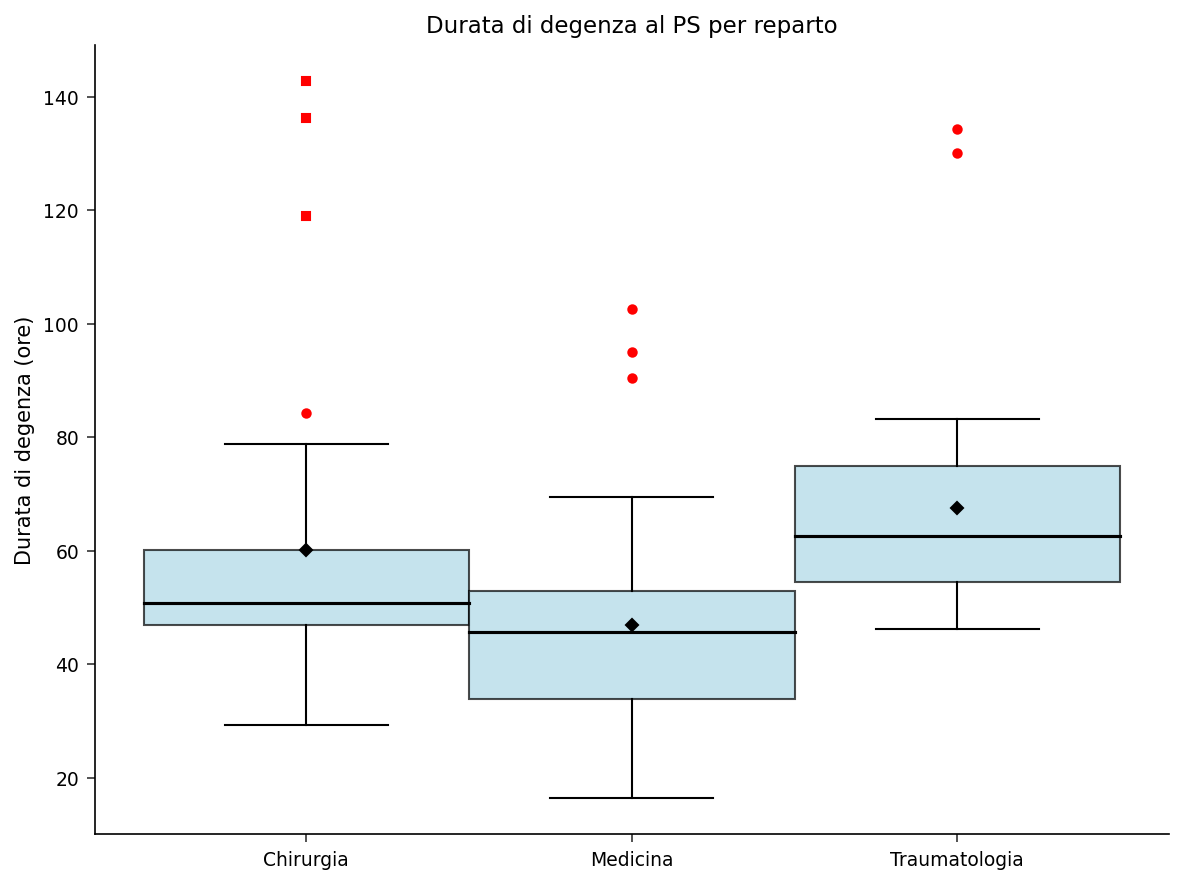

In [3]:
TITOLO "Durata di degenza al PS per reparto";
PROCEDURA boxplot DATI=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle = schematic
      nohlabel;
ESEGUIRE;

## Passo 4 — Sovrapporre una linea di andamento medio

Per rendere esplicito il gradiente da servizio a servizio, aggiungiamo `BOXCONNECT=MEAN`. PROC BOXPLOT traccia quindi una linea di collegamento che passa per la media di ogni box (i marcatori a rombo), trasformando le tre distribuzioni separate in un unico andamento leggibile. Poiché i reparti sono ordinati Medicina → Chirurgia → Traumatologia, la linea di collegamento crescente riassume in un solo tratto l'escalation della durata media di degenza — un'indicazione utile per una dashboard operativa.

                     Durata di degenza al PS per reparto - Andamento medio                      

                     Durata di degenza al PS per reparto - Andamento medio

                                     The BOXPLOT Procedure

Schematic Plots for Durata di degenza (ore)

Reparto               N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgia            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicina             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Traumatologia        30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Durata di degenza al PS per reparto - Andamento medio.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


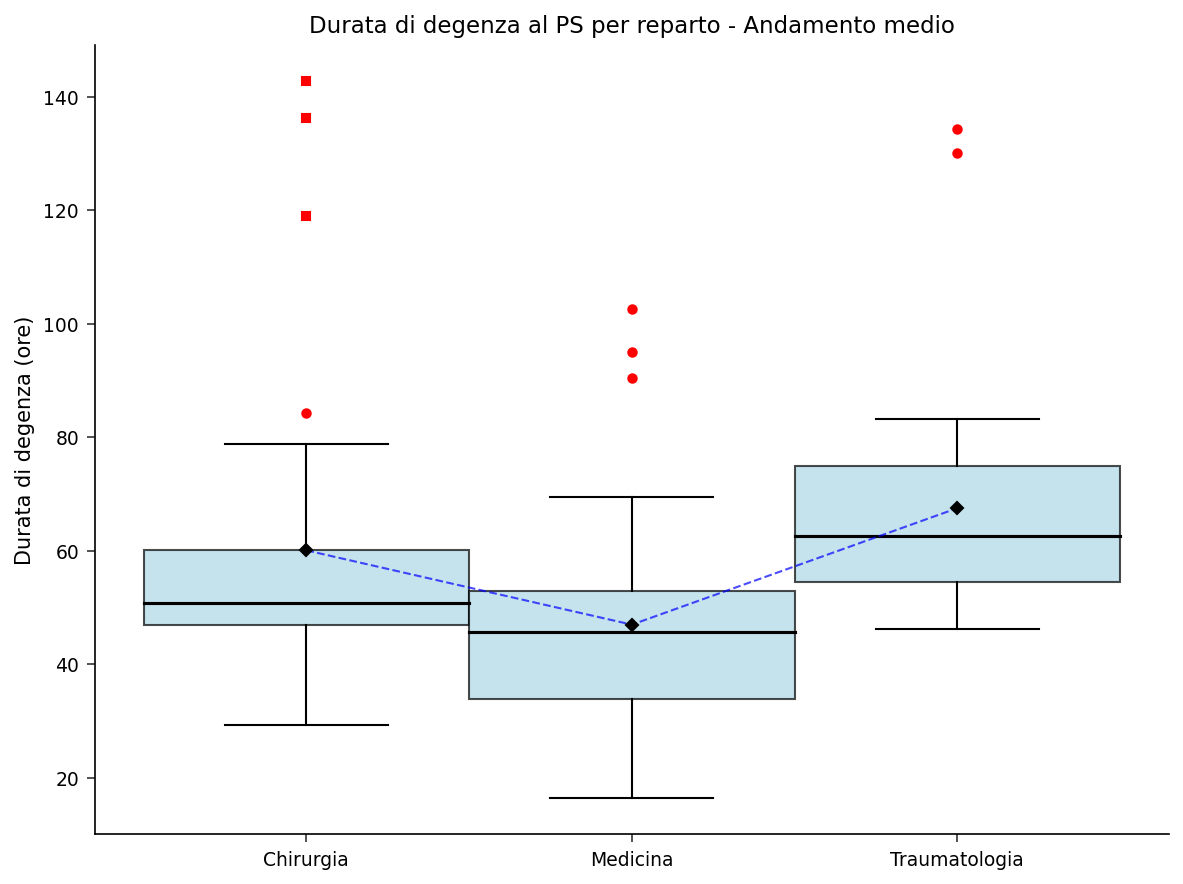

In [4]:
TITOLO "Durata di degenza al PS per reparto - Andamento medio";
PROCEDURA boxplot DATI=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle    = schematic
      boxconnect  = mean
      nohlabel;
ESEGUIRE;

## Passo 5 — Layout orizzontale

Lo stesso confronto si legge naturalmente ruotato di lato. Aggiungere `HORIZONTAL` scambia gli assi, così i box scorrono da sinistra a destra con la risposta sull'asse x — un layout che si adatta meglio quando i nomi dei servizi sono lunghi o numerosi, e che molte dashboard operative preferiscono. Le statistiche sono identiche alla vista verticale; cambia solo l'orientamento.

                       Durata di degenza al PS per reparto - Orizzontale                        

                       Durata di degenza al PS per reparto - Orizzontale

                                     The BOXPLOT Procedure

Schematic Plots for Durata di degenza (ore)

Reparto               N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
Chirurgia            36        29.30        46.90        50.70        60.02       142.80        60.04        25.18
Medicina             34        16.30        33.90        45.65        52.80       102.60        46.94        19.70
Traumatologia        30        46.10        54.53        62.50        74.95       134.40        67.48        20.78
------------------------------------------------------------------------------------------------------------



NOTE: Option TITLE changed to Durata di degenza al PS per reparto - Orizzontale.
NOTE: PROC BOXPLOT data=ed_los

NOTE: ODS plot written: boxplot.spec.json


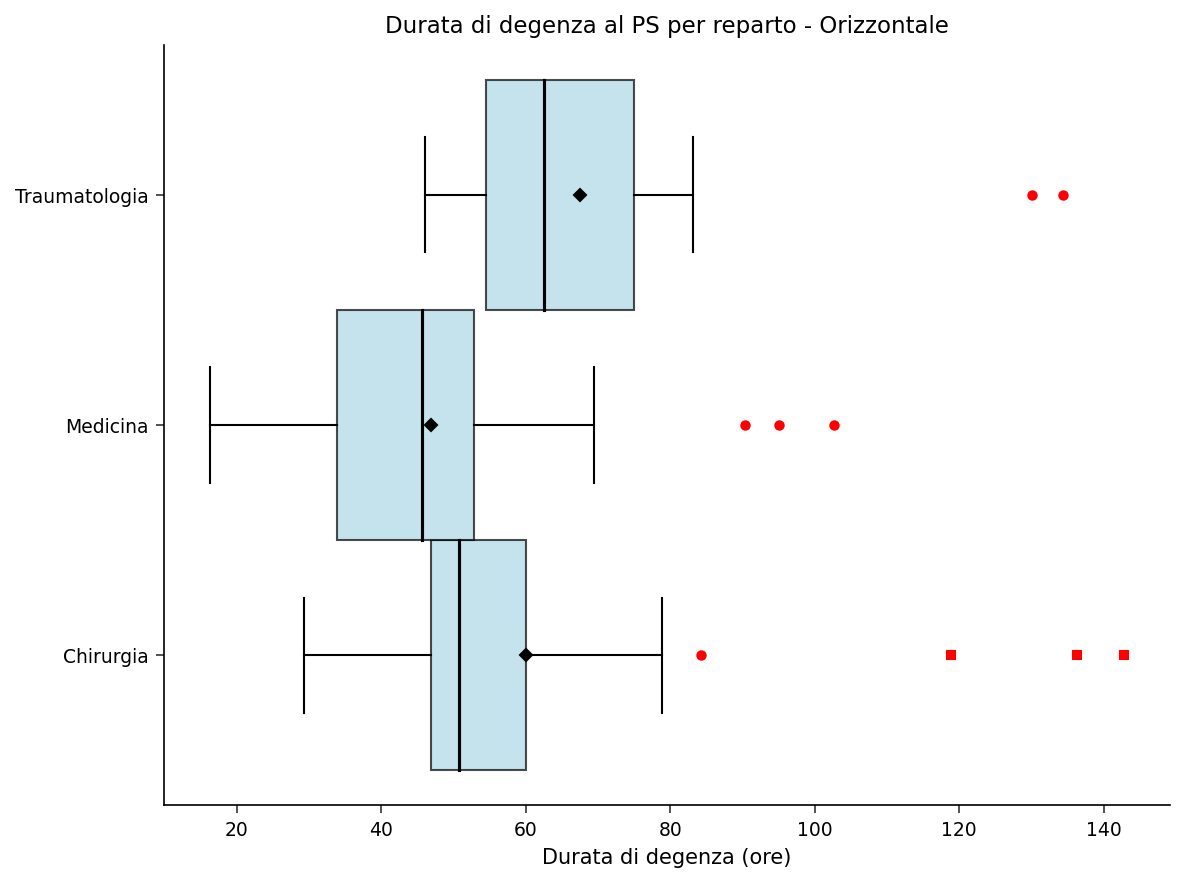

In [5]:
TITOLO "Durata di degenza al PS per reparto - Orizzontale";
PROCEDURA boxplot DATI=ed_los;
   PLOT LOS_Hours*Department /
      boxstyle   = schematic
      horizontal
      nohlabel;
ESEGUIRE;

## Interpretazione dei risultati

I box plot e la relativa tabella di statistiche traducono i dati grezzi della LOS in un quadro operativamente utilizzabile:

- **Un chiaro gradiente tra servizi.** La durata mediana di degenza cresce in modo monotono tra i tre servizi: **Medicina 40.0 h → Chirurgia 50.4 h → Traumatologia 60.5 h**. Le medie raccontano la stessa storia (41.6, 54.6, 62.8 h), e la linea `BOXCONNECT=MEAN` del Passo 4 disegna quell'escalation come un unico andamento crescente. I pazienti di Traumatologia rimangono in media circa il 50% più a lungo dei pazienti di Medicina.

- **La variabilità conta quanto la mediana.** Lo scarto interquartile (l'altezza del box) è più ampio per la Medicina (Q1 32.8 h fino a Q3 51.2 h, una dispersione di 18.3 ore) e più stretto per la Traumatologia (Q1 54.5 h fino a Q3 68.5 h, una dispersione di 14.0 ore). La Medicina è quindi non solo il servizio più breve ma anche il meno prevedibile — la proprietà che complica le previsioni di gestione dei posti letto.

- **I valori anomali segnalano i casi di stazionamento.** I baffi schematici si fermano a 1.5 × IQR, quindi i tre punti rossi sopra il baffo superiore della Chirurgia (con picco a 84.3 h) risaltano come autentici accessi di lunga degenza — esattamente i casi di stazionamento che consumano ore-letto in modo sproporzionato. Medicina e Traumatologia non mostrano punti oltre i loro baffi in questo campione.

- **L'intervallo racconta la storia della pianificazione della capacità.** Le degenze osservate vanno da 16.3–69.5 h in Medicina, 29.3–84.3 h in Chirurgia e 46.1–83.2 h in Traumatologia. La Traumatologia non produce mai una degenza breve (il suo minimo, 46.1 h, supera la mediana della Medicina), che è ciò che un team operativo si aspetterebbe dal servizio più intensivo in termini di risorse.

Insieme, queste viste offrono a un team dirigenziale del pronto soccorso una base difendibile e consapevole della distribuzione per la dotazione di personale e la pianificazione della capacità — molto più informativa del semplice confronto delle LOS medie dipartimentali.